# NYC Taxi Demand Forecasting — Historical Demand

This notebook extends the January 2025 ingestion prototype across the full 2025 calendar year, constructs a balanced zone-hour demand panel, and examines recurring temporal and spatial demand patterns.

## Objective

1. Ingest and validate monthly NYC TLC Yellow Taxi trip files for 2025.
2. Aggregate individual trips into hourly pickup demand by zone.
3. Restrict modeling to zones with sufficient historical activity while retaining nearly all observed demand.
4. Construct and save a complete zone-hour panel for downstream forecasting.
5. Characterize temporal seasonality and spatial differences that motivate later forecasting features.

All transformations preserve chronological structure for downstream one-hour-ahead forecasting.


## 1. Imports

In [151]:
import pandas as pd
from pathlib import Path
from urllib.request import urlretrieve
import matplotlib.pyplot as plt

## 2. Define Modeling Period

The initial historical demand dataset covers January through December 2025. A full calendar year provides repeated weekly demand patterns and seasonal variation while keeping the project computationally manageable.

January 2025 was previously used to prototype and validate the raw-data ingestion process.

In [152]:
months = pd.date_range(
    start="2025-01-01",
    end="2025-12-01",
    freq="MS"
)

months

DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01'],
              dtype='datetime64[ns]', freq='MS')

## 3. Generate Monthly File Names

Construct the expected NYC TLC Yellow Taxi filename for each month in the modeling period. This allows the same ingestion logic to be applied systematically across all monthly files.

In [153]:
for month in months:
    filename = f"yellow_tripdata_{month.strftime('%Y-%m')}.parquet"
    print(filename)

yellow_tripdata_2025-01.parquet
yellow_tripdata_2025-02.parquet
yellow_tripdata_2025-03.parquet
yellow_tripdata_2025-04.parquet
yellow_tripdata_2025-05.parquet
yellow_tripdata_2025-06.parquet
yellow_tripdata_2025-07.parquet
yellow_tripdata_2025-08.parquet
yellow_tripdata_2025-09.parquet
yellow_tripdata_2025-10.parquet
yellow_tripdata_2025-11.parquet
yellow_tripdata_2025-12.parquet


## 4. Construct Local File Paths

Combine each expected monthly filename with the raw taxi-data directory so the ingestion pipeline can locate files consistently.

In [154]:
taxi_dir = Path("../data/raw/taxi")

file_paths = [
    taxi_dir / f"yellow_tripdata_{month.strftime('%Y-%m')}.parquet"
    for month in months
]

file_paths

[PosixPath('../data/raw/taxi/yellow_tripdata_2025-01.parquet'),
 PosixPath('../data/raw/taxi/yellow_tripdata_2025-02.parquet'),
 PosixPath('../data/raw/taxi/yellow_tripdata_2025-03.parquet'),
 PosixPath('../data/raw/taxi/yellow_tripdata_2025-04.parquet'),
 PosixPath('../data/raw/taxi/yellow_tripdata_2025-05.parquet'),
 PosixPath('../data/raw/taxi/yellow_tripdata_2025-06.parquet'),
 PosixPath('../data/raw/taxi/yellow_tripdata_2025-07.parquet'),
 PosixPath('../data/raw/taxi/yellow_tripdata_2025-08.parquet'),
 PosixPath('../data/raw/taxi/yellow_tripdata_2025-09.parquet'),
 PosixPath('../data/raw/taxi/yellow_tripdata_2025-10.parquet'),
 PosixPath('../data/raw/taxi/yellow_tripdata_2025-11.parquet'),
 PosixPath('../data/raw/taxi/yellow_tripdata_2025-12.parquet')]

In [155]:
for path in file_paths:
    print(path.name, path.exists())

yellow_tripdata_2025-01.parquet True
yellow_tripdata_2025-02.parquet True
yellow_tripdata_2025-03.parquet True
yellow_tripdata_2025-04.parquet True
yellow_tripdata_2025-05.parquet True
yellow_tripdata_2025-06.parquet True
yellow_tripdata_2025-07.parquet True
yellow_tripdata_2025-08.parquet True
yellow_tripdata_2025-09.parquet True
yellow_tripdata_2025-10.parquet True
yellow_tripdata_2025-11.parquet True
yellow_tripdata_2025-12.parquet True


## 5. Validate Programmatic Monthly Download

Use February 2025 to validate programmatic downloading and inspect whether a nominal monthly TLC file contains timestamps outside its intended calendar month. The reusable ingestion function later generalizes this process across all months.


In [156]:
month = months[1]

filename = f"yellow_tripdata_{month.strftime('%Y-%m')}.parquet"
url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{filename}"

print(filename)
print(url)

yellow_tripdata_2025-02.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-02.parquet


In [157]:
feb_path = taxi_dir / filename

if not feb_path.exists():
    urlretrieve(url, feb_path)

print(feb_path.exists())


True


In [158]:
feb = pd.read_parquet(feb_path)

feb.shape

(3577543, 20)

In [159]:
feb["tpep_pickup_datetime"].min(), feb["tpep_pickup_datetime"].max()

(Timestamp('2025-01-31 22:22:53'), Timestamp('2025-03-01 00:06:32'))

In [160]:
feb_mask = (
    (feb["tpep_pickup_datetime"] >= "2025-02-01") &
    (feb["tpep_pickup_datetime"] < "2025-03-01")
)

feb_mask.value_counts()

tpep_pickup_datetime
True     3577512
False         31
Name: count, dtype: int64

## 6. Generalize Monthly Date Filtering

Monthly TLC files can contain a small number of pickup timestamps outside their nominal calendar month. Define each month's start and end dynamically so the same

In [161]:
month = months[1]

month_start = month

month_end = month + pd.offsets.MonthBegin(1)

print("Start:", month_start)

print("End:", month_end)

Start: 2025-02-01 00:00:00
End: 2025-03-01 00:00:00


## 7. Build Reusable Monthly Ingestion Function

Encapsulate the validated monthly ingestion logic into a reusable function. For each month, the function will construct the expected filename, download the file if necessary, load the raw trip records, and restrict pickup timestamps to the intended calendar month.

In [162]:
def load_month(month, taxi_dir):
    filename = f"yellow_tripdata_{month.strftime('%Y-%m')}.parquet"
    file_path = taxi_dir / filename

    if not file_path.exists():
        url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{filename}"
        print(f"Downloading {filename}...")
        urlretrieve(url, file_path)

    df = pd.read_parquet(file_path)

    month_start = month
    month_end = month_start + pd.offsets.MonthBegin(1)

    in_month = (
        (df["tpep_pickup_datetime"] >= month_start) &
        (df["tpep_pickup_datetime"] < month_end)
    )

    raw_rows = len(df)
    df = df.loc[in_month].copy()
    removed_rows = raw_rows - len(df)

    print(
        f"{month.strftime('%Y-%m')}: "
        f"{raw_rows:,} raw rows → "
        f"{len(df):,} in-month rows "
        f"({removed_rows:,} removed)"
    )

    return df

In [163]:
monthly_dfs = []

for month in months:
    df_month = load_month(month, taxi_dir)
    monthly_dfs.append(df_month)

2025-01: 3,475,226 raw rows → 3,475,204 in-month rows (22 removed)
2025-02: 3,577,543 raw rows → 3,577,512 in-month rows (31 removed)
2025-03: 4,145,257 raw rows → 4,145,224 in-month rows (33 removed)
2025-04: 3,970,553 raw rows → 3,970,546 in-month rows (7 removed)
2025-05: 4,591,845 raw rows → 4,591,821 in-month rows (24 removed)
2025-06: 4,322,960 raw rows → 4,322,940 in-month rows (20 removed)
2025-07: 3,898,963 raw rows → 3,898,956 in-month rows (7 removed)
2025-08: 3,574,091 raw rows → 3,574,074 in-month rows (17 removed)
2025-09: 4,251,015 raw rows → 4,251,008 in-month rows (7 removed)
2025-10: 4,428,699 raw rows → 4,428,686 in-month rows (13 removed)
2025-11: 4,181,444 raw rows → 4,181,420 in-month rows (24 removed)
2025-12: 4,305,006 raw rows → 4,304,997 in-month rows (9 removed)


## 8. Construct Hourly Zone-Level Demand

Aggregate individual taxi trips into hourly pickup counts by pickup zone. This transforms the trip-level data into the time-series structure needed for demand forecasting.

In [164]:
hourly_months = []

for df in monthly_dfs:
    df = df[["tpep_pickup_datetime", "PULocationID"]].copy()

    df["pickup_hour"] = df["tpep_pickup_datetime"].dt.floor("h")

    hourly = (
        df.groupby(["pickup_hour", "PULocationID"])
          .size()
          .reset_index(name="trip_count")
    )

    hourly_months.append(hourly)

In [165]:
hourly_demand = pd.concat(hourly_months, ignore_index=True)

hourly_demand.shape

(1430274, 3)

In [166]:
hourly_demand.head()

,pickup_hour,PULocationID,trip_count
0,2025-01-01,4,28
1,2025-01-01,7,12
2,2025-01-01,9,1
3,2025-01-01,10,1
4,2025-01-01,12,1


In [167]:
print("Start:", hourly_demand["pickup_hour"].min())
print("End:", hourly_demand["pickup_hour"].max())
print("Rows:", f"{len(hourly_demand):,}")

Start: 2025-01-01 00:00:00
End: 2025-12-31 23:00:00
Rows: 1,430,274


## 9. Evaluate Zone Coverage

Examine pickup volume and temporal coverage across taxi zones before constructing a complete hourly panel. This avoids treating rarely observed or non-service zones as equivalent to meaningful Yellow Taxi demand markets.

In [168]:
zone_summary = (
    hourly_demand.groupby("PULocationID")
    .agg(
        total_trips=("trip_count", "sum"),
        active_hours=("pickup_hour", "nunique"),
        avg_trips_per_active_hour=("trip_count", "mean")
    )
    .sort_values("total_trips", ascending=False)
)

zone_summary

,total_trips,active_hours,avg_trips_per_active_hour
PULocationID,,,
237,2125557,8738,243.254406
161,2089747,8758,238.610071
132,2062443,8755,235.573158
236,1874805,8692,215.693166
186,1543158,8759,176.179701
...,...,...,...
204,29,28,1.035714
5,20,20,1.000000
199,18,16,1.125000


In [169]:
print("Number of observed pickup zones:", len(zone_summary))
print()
print(zone_summary.tail(20))

Number of observed pickup zones: 262

              total_trips  active_hours  avg_trips_per_active_hour
PULocationID                                                      
118                   302           284                   1.063380
59                    284           273                   1.040293
30                    244           238                   1.025210
172                   230           222                   1.036036
251                   211           199                   1.060302
206                   182           175                   1.040000
111                   169           162                   1.043210
156                   160           149                   1.073826
245                   136           131                   1.038168
176                   104            99                   1.050505
109                    79            75                   1.053333
187                    73            69                   1.057971
2                      6

In [170]:
total_hours = hourly_demand["pickup_hour"].nunique()

zone_summary["hour_coverage"] = (
    zone_summary["active_hours"] / total_hours
)

zone_summary[
    ["total_trips", "active_hours", "hour_coverage"]
].sort_values("total_trips", ascending=False)

,total_trips,active_hours,hour_coverage
PULocationID,,,
237,2125557,8738,0.997602
161,2089747,8758,0.999886
132,2062443,8755,0.999543
236,1874805,8692,0.992351
186,1543158,8759,1.000000
...,...,...,...
204,29,28,0.003197
5,20,20,0.002283
199,18,16,0.001827


In [171]:
for threshold in [0.10, 0.25, 0.50, 0.75, 0.90]:
    n_zones = (zone_summary["hour_coverage"] >= threshold).sum()
    print(f"{threshold:.0%} coverage: {n_zones} zones")

10% coverage: 230 zones
25% coverage: 217 zones
50% coverage: 174 zones
75% coverage: 114 zones
90% coverage: 86 zones


In [172]:
zone_summary[
    (zone_summary["hour_coverage"] >= 0.25) &
    (zone_summary["hour_coverage"] <= 0.75)
].sort_values("hour_coverage")

,total_trips,active_hours,avg_trips_per_active_hour,hour_coverage
PULocationID,,,,
207,3611,2214,1.630985,0.252769
183,2872,2215,1.296614,0.252883
178,3006,2281,1.317843,0.260418
201,3032,2314,1.310285,0.264185
98,2947,2355,1.251380,0.268866
...,...,...,...,...
40,18628,6220,2.994855,0.710127
63,15917,6301,2.526107,0.719374
28,14562,6374,2.284594,0.727709


In [173]:
coverage_threshold = 0.50

selected_zones = zone_summary.index[
    zone_summary["hour_coverage"] >= coverage_threshold
]

print("Selected zones:", len(selected_zones))
print(
    "Share of 2025 trips retained:",
    f"{zone_summary.loc[selected_zones, 'total_trips'].sum() / zone_summary['total_trips'].sum():.2%}"
)

Selected zones: 174
Share of 2025 trips retained: 99.47%


**Observation:** A 50% hourly-coverage threshold retains 174 pickup zones while preserving 99.47% of all observed 2025 Yellow Taxi trips. This removes extremely sparse zones that provide little meaningful hourly forecasting signal without materially reducing coverage of overall demand.

The threshold is defined before model fitting and is based on historical activity rather than downstream predictive performance.


## 10. Build Complete Hourly Zone Panel

Construct a balanced panel containing every hour of 2025 for each selected pickup zone. Zone-hours with no observed pickups are represented explicitly as zero demand.

In [174]:
all_hours = pd.date_range(
    start="2025-01-01 00:00:00",
    end="2025-12-31 23:00:00",
    freq="h"
)

full_index = pd.MultiIndex.from_product(
    [all_hours, selected_zones],
    names=["pickup_hour", "PULocationID"]
)

demand_panel = (
    hourly_demand
    .set_index(["pickup_hour", "PULocationID"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

demand_panel.shape

(1524240, 3)

In [175]:
print("Rows:", f"{len(demand_panel):,}")
print("Zones:", demand_panel["PULocationID"].nunique())
print("Hours:", demand_panel["pickup_hour"].nunique())
print("Missing values:", demand_panel.isna().sum().sum())
print("Zero-demand rows:", (demand_panel["trip_count"] == 0).sum())

Rows: 1,524,240
Zones: 174
Hours: 8760
Missing values: 0
Zero-demand rows: 266318


In [176]:
demand_panel.head(10)

,pickup_hour,PULocationID,trip_count
0,2025-01-01,237,261
1,2025-01-01,161,274
2,2025-01-01,132,233
3,2025-01-01,236,128
4,2025-01-01,186,155
5,2025-01-01,230,0
6,2025-01-01,162,147
7,2025-01-01,142,354
8,2025-01-01,170,189
9,2025-01-01,234,253


## 11. Save Processed Hourly Demand

Save the validated hourly zone-level demand panel as a Parquet file for use in downstream analysis and modeling notebooks.

In [177]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

output_path = processed_dir / "yellow_taxi_hourly_demand_2025.parquet"

demand_panel.to_parquet(output_path, index=False)

print(f"Saved to: {output_path}")
print(f"File size: {output_path.stat().st_size / 1_000_000:.1f} MB")

Saved to: ../data/processed/yellow_taxi_hourly_demand_2025.parquet
File size: 1.8 MB


In [178]:
check = pd.read_parquet(output_path)

print("Shape:", check.shape)
print("Date range:", check["pickup_hour"].min(), "to", check["pickup_hour"].max())
print("Zones:", check["PULocationID"].nunique())
print("Missing values:", check.isna().sum().sum())

Shape: (1524240, 3)
Date range: 2025-01-01 00:00:00 to 2025-12-31 23:00:00
Zones: 174


Missing values: 0


In [179]:
print(
    "Share of 2025 trips retained:",
    f"{zone_summary.loc[selected_zones, 'total_trips'].sum() / zone_summary['total_trips'].sum():.2%}"
)

Share of 2025 trips retained: 99.47%


## 12. Analyze Overall Demand Patterns

Examine aggregate Yellow Taxi demand across the selected pickup zones to identify temporal patterns that may be useful for forecasting.

In [180]:
total_trips = demand_panel["trip_count"].sum()

print(f"Total trips represented: {total_trips:,}")
print(f"Average trips per hour-zone: {demand_panel['trip_count'].mean():.2f}")
print(f"Median trips per hour-zone: {demand_panel['trip_count'].median():.0f}")
print(f"Maximum trips in one hour-zone: {demand_panel['trip_count'].max():,}")

Total trips represented: 48,462,686
Average trips per hour-zone: 31.79
Median trips per hour-zone: 4
Maximum trips in one hour-zone: 1,300


In [181]:
city_hourly = (
    demand_panel
    .groupby("pickup_hour", as_index=False)["trip_count"]
    .sum()
)

city_hourly.head()

,pickup_hour,trip_count
0,2025-01-01 00:00:00,7315
1,2025-01-01 01:00:00,8392
2,2025-01-01 02:00:00,7178
3,2025-01-01 03:00:00,4864
4,2025-01-01 04:00:00,2893


In [182]:
city_daily = (
    city_hourly
    .set_index("pickup_hour")["trip_count"]
    .resample("D")
    .sum()
    .reset_index()
)

city_daily.head()

,pickup_hour,trip_count
0,2025-01-01,89664
1,2025-01-02,84573
2,2025-01-03,91008
3,2025-01-04,97626
4,2025-01-05,79459


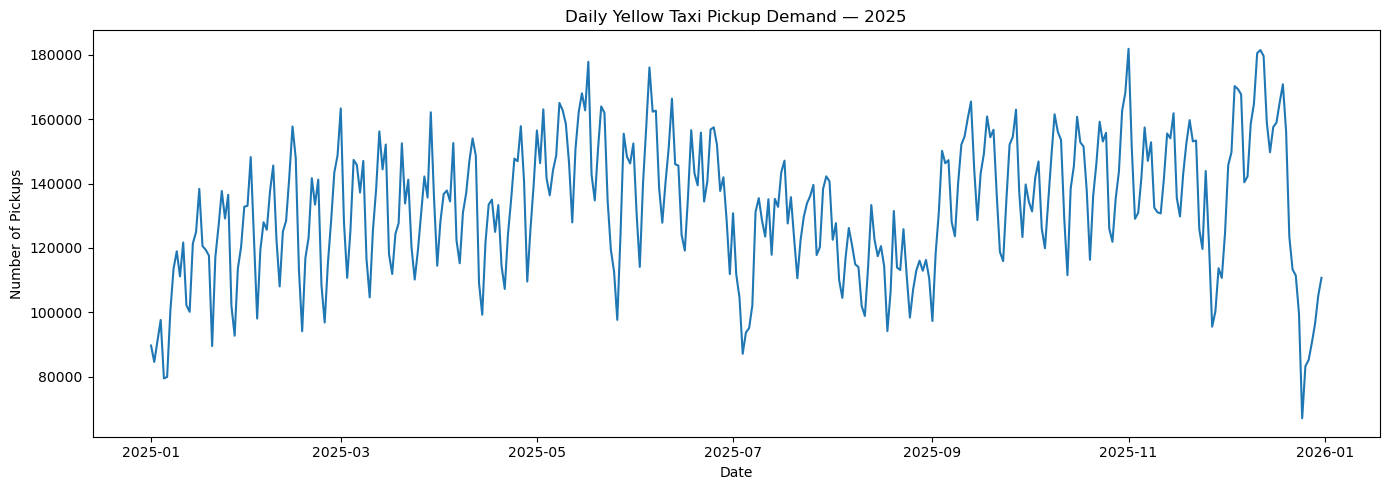

In [183]:
plt.figure(figsize=(14, 5))
plt.plot(city_daily["pickup_hour"], city_daily["trip_count"])
plt.title("Daily Yellow Taxi Pickup Demand — 2025")
plt.xlabel("Date")
plt.ylabel("Number of Pickups")
plt.tight_layout()
plt.show()

**Observation:** Daily demand shows strong recurring weekly variation as well as broader seasonal changes throughout the year. Demand generally increases from winter into spring, declines during parts of the summer, and strengthens again during the fall. Several unusually low-demand periods are also visible, particularly around major holiday periods.

These patterns suggest that calendar features such as hour of day, day of week, month, and holiday indicators may be useful for forecasting. The strong recurring temporal structure also motivates testing lag-based features that capture recent and weekly historical demand.

## 13. Examine Hourly and Weekly Seasonality

Measure how average Yellow Taxi demand varies by hour of day and day of week to identify recurring temporal structure relevant to forecasting.

In [184]:
city_hourly["hour"] = city_hourly["pickup_hour"].dt.hour
city_hourly["day_of_week"] = city_hourly["pickup_hour"].dt.dayofweek

In [185]:
hourly_pattern = (
    city_hourly.groupby("hour")["trip_count"]
    .mean()
)

hourly_pattern

hour
0     4196.032877
1     2768.635616
2     1821.950685
3     1242.479452
4      973.241096
5     1030.057534
6     2039.446575
7     3738.410959
8     5071.030137
9     5437.257534
10    5674.772603
11    6090.186301
12    6639.013699
13    6962.961644
14    7472.553425
15    7784.323288
16    8009.646575
17    8985.249315
18    9486.797260
19    8390.057534
20    7717.854795
21    7923.142466
22    7449.101370
23    5870.279452
Name: trip_count, dtype: float64

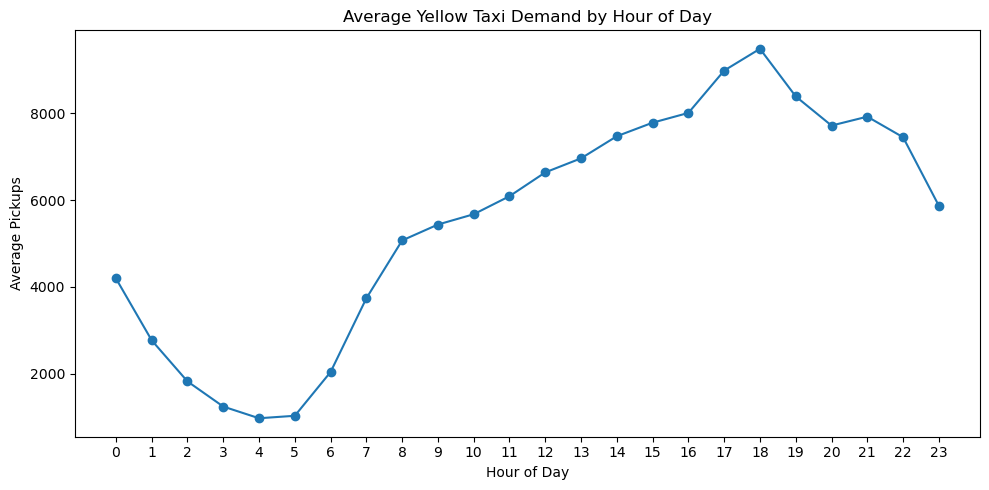

In [186]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker="o")
plt.title("Average Yellow Taxi Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Pickups")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

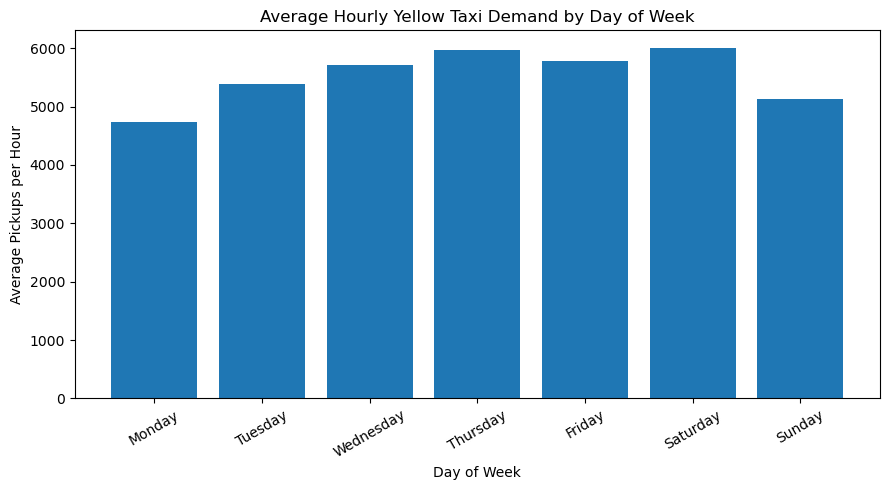

In [187]:
day_names = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekly_pattern = (
    city_hourly.groupby("day_of_week")["trip_count"]
    .mean()
    .reindex(range(7))
)

plt.figure(figsize=(9, 5))
plt.bar(day_names, weekly_pattern.values)
plt.title("Average Hourly Yellow Taxi Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Pickups per Hour")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observation:** Yellow Taxi demand varies substantially across both hour of day and day of week. Hourly demand reaches its lowest levels around 4–5 AM, rises steadily throughout the morning and afternoon, and peaks around 6 PM before declining into the night. Weekly demand generally increases from Monday through Saturday, with Saturday showing the highest average hourly demand and Monday the lowest.

These recurring daily and weekly cycles support testing hour-of-day and day-of-week features in the forecasting model. They also suggest that demand at the same hour on previous days or weeks may provide useful predictive information.

## 14. Examine Zone-Level Demand Differences

Compare demand across pickup zones to determine how strongly taxi activity varies spatially and whether zone identity should be represented in the forecasting model.

In [188]:
zone_demand = (
    demand_panel
    .groupby("PULocationID")["trip_count"]
    .agg(["mean", "median", "max", "sum"])
    .sort_values("mean", ascending=False)
)

zone_demand.head(10)

,mean,median,max,sum
PULocationID,,,,
237,242.643493,246.0,945,2125557
161,238.555594,215.0,891,2089747
132,235.438699,212.0,741,2062443
236,214.018836,209.0,779,1874805
186,176.159589,195.0,591,1543158
230,173.104795,168.0,761,1516398
162,172.166210,172.0,651,1508176
142,158.402169,170.0,775,1387603
170,147.760616,161.0,448,1294383


In [190]:
zone_lookup_path = taxi_dir / "taxi_zone_lookup.csv"
zone_lookup = pd.read_csv(zone_lookup_path)

zone_lookup.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [191]:
zone_demand_named = (
    zone_demand
    .reset_index()
    .merge(
        zone_lookup[["LocationID", "Borough", "Zone"]],
        left_on="PULocationID",
        right_on="LocationID",
        how="left"
    )
)

zone_demand_named[
    ["PULocationID", "Borough", "Zone", "mean", "median", "max", "sum"]
].head(15)

,PULocationID,Borough,Zone,mean,median,max,sum
0,237,Manhattan,Upper East Side South,242.643493,246.0,945,2125557
1,161,Manhattan,Midtown Center,238.555594,215.0,891,2089747
2,132,Queens,JFK Airport,235.438699,212.0,741,2062443
3,236,Manhattan,Upper East Side North,214.018836,209.0,779,1874805
4,186,Manhattan,Penn Station/Madison Sq West,176.159589,195.0,591,1543158
5,230,Manhattan,Times Sq/Theatre District,173.104795,168.0,761,1516398
6,162,Manhattan,Midtown East,172.166210,172.0,651,1508176
7,142,Manhattan,Lincoln Square East,158.402169,170.0,775,1387603
8,170,Manhattan,Murray Hill,147.760616,161.0,448,1294383
9,234,Manhattan,Union Sq,147.675228,139.0,527,1293635


In [ ]:
top_zones = zone_demand_named.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_zones["Zone"][::-1],
    top_zones["mean"][::-1]
)
plt.title("Top 15 Pickup Zones by Average Hourly Demand")
plt.xlabel("Average Pickups per Hour")
plt.ylabel("Pickup Zone")
plt.tight_layout()
plt.show()


**Observation:** Yellow Taxi demand varies substantially across pickup zones. The highest-demand locations are concentrated in Manhattan, particularly Midtown and the Upper East Side, while JFK and LaGuardia airports also rank among the busiest zones. Average hourly demand in the leading zones exceeds 200 pickups per hour, demonstrating substantial spatial differences in baseline demand.

These differences support modeling demand at the zone level rather than relying only on citywide patterns. Zone identity and zone-specific historical demand may therefore provide important predictive information.

## 15. Key Findings

**Observation:** Historical Yellow Taxi demand exhibits strong temporal and spatial structure. Demand varies systematically by hour of day and day of week, shows broader seasonal changes across the year, and differs substantially across pickup zones. The 174 zones selected for modeling retain 99.47% of observed 2025 trips while excluding extremely sparse locations that provide little useful hourly forecasting signal.

These findings establish the foundation for the forecasting pipeline. Subsequent modeling should test calendar features, zone information, and lagged historical demand while preserving chronological ordering to prevent future information from leaking into training.

## 16. Streamlit Export

Create compact zone-level summaries from the final 174-zone balanced demand panel for use by the Streamlit application. These exports allow the app to provide interactive demand exploration without loading the full 1.5-million-row modeling dataset.


In [ ]:
app_data_dir = Path("../data/app")
app_data_dir.mkdir(parents=True, exist_ok=True)

# Use the final balanced 174-zone panel rather than the pre-filtered hourly data.
streamlit_demand = demand_panel.copy()

streamlit_demand["hour"] = streamlit_demand["pickup_hour"].dt.hour
streamlit_demand["day_of_week"] = streamlit_demand["pickup_hour"].dt.dayofweek

# Average demand by zone and hour of day.
zone_hourly_patterns = (
    streamlit_demand
    .groupby(["PULocationID", "hour"], as_index=False)["trip_count"]
    .mean()
    .rename(columns={"trip_count": "average_demand"})
)

# Average demand by zone and day of week.
zone_weekday_patterns = (
    streamlit_demand
    .groupby(["PULocationID", "day_of_week"], as_index=False)["trip_count"]
    .mean()
    .rename(columns={"trip_count": "average_demand"})
)

# Retain readable taxi-zone names for the Streamlit selector.
zone_mapping = (
    pd.DataFrame({"PULocationID": sorted(selected_zones)})
    .merge(
        zone_lookup[["LocationID", "Borough", "Zone"]],
        left_on="PULocationID",
        right_on="LocationID",
        how="left"
    )
    .drop(columns="LocationID")
)

zone_hourly_patterns.to_parquet(
    app_data_dir / "zone_hourly_patterns.parquet",
    index=False
)

zone_weekday_patterns.to_parquet(
    app_data_dir / "zone_weekday_patterns.parquet",
    index=False
)

zone_mapping.to_parquet(
    app_data_dir / "zone_mapping.parquet",
    index=False
)

print("Hourly pattern rows:", len(zone_hourly_patterns))
print("Weekday pattern rows:", len(zone_weekday_patterns))
print("Zone mapping rows:", len(zone_mapping))
print("Zones represented:", zone_mapping["PULocationID"].nunique())


**Observation:** The Streamlit exports are built from the final balanced panel used by the forecasting pipeline, so the interactive application represents the same 174 pickup zones evaluated by the models. This produces 4,176 zone-hour-of-day summaries, 1,218 zone-weekday summaries, and a 174-row zone-name lookup while keeping the application data small and fast to load.
